
$\text{Janitza Current} = k I_{sm}  + I_{um} + \text{NTL}+ \sigma $

Where $k$ is CT scaling factor, $I_{sm}$ is the smart meter sum, $I_{um}$ is the unmetered load,NTL is the non techinal losses and $\sigma$ is the noise

In [187]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import math

def parse_dnr(d):
    """
    'D0411' -> 411
    'D1354' -> 1354
    """
    s = str(d).strip()
    if not s or not s.startswith("D"):
        return None
    digits = s[1:].lstrip("0")  # remove 'D' and leading zeros
    if digits == "":
        return None
    return int(digits)


def compute_ct_diagnostics(
    merged: pd.DataFrame,
    min_points: int = 50,
    min_current: float = 5.0,
) -> pd.DataFrame:
    """
    Per-substation diagnostics to detect CT scaling vs unmetered load.

    Expects columns in merged:
      substation_id, ts, I_total_sm, I_total_jn, n_mps, per_completed

    Assumes:
      - Janitza should be an upper bound for true current
        → in a physically consistent situation, I_total_sm <= I_total_jn
        (ignoring noise / mapping mistakes).
    """
    rows = []

    for sid, g in merged.groupby("substation_id"):
        g = g.copy()

        # Filter out very low currents (ratios get crazy near zero)
        mask = (g["I_total_sm"].abs() > min_current) & (g["I_total_jn"].abs() > min_current)
        g = g[mask]
        if len(g) < min_points:
            continue  # not enough data

        x = g["I_total_sm"].values
        y = g["I_total_jn"].values

        # --- 1) Physical sanity: how often is SMD > Janitza? ---
        # This should basically never happen if topology + CT are correct
        sm_gt_jn = (g["I_total_sm"] > g["I_total_jn"])
        frac_sm_gt_jn = sm_gt_jn.mean()

        # --- 2) Unconstrained linear fit: y ≈ alpha * x + beta ---
        # (useful for R² / "does it look like a line?")
        alpha_ls, beta = np.polyfit(x, y, 1)

        y_pred = alpha_ls * x + beta
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

        # Correlation (shape similarity)
        corr = g["I_total_jn"].corr(g["I_total_sm"])

        # --- 3) Ratio-based view: y/x distribution ---
        ratio = g["I_total_jn"] / g["I_total_sm"]
        ratio = ratio.replace([np.inf, -np.inf], np.nan).dropna()
        ratio_median = float(ratio.median()) if not ratio.empty else np.nan
        ratio_std = float(ratio.std()) if not ratio.empty else np.nan
        ratio_min = float(ratio.min()) if not ratio.empty else np.nan
        ratio_p05 = float(ratio.quantile(0.05)) if len(ratio) > 0 else np.nan

        # --- 4) "CT scaling" factor under your physical constraint ---
        # Idea:
        #   - If JD is an upper bound, any scaling alpha must satisfy:
        #       alpha * I_total_sm <= I_total_jn  for all timestamps
        #     → alpha <= min_t (I_total_jn / I_total_sm) = ratio_min
        #
        #   - We also want alpha close to the "best" slope.
        #   - So we take the OLS slope *through origin* (no intercept)
        #     and then clip it to respect the constraint.
        #
        # OLS with intercept 0 : alpha0 = sum(x*y) / sum(x^2)
        if np.sum(x**2) > 0:
            alpha0 = float(np.sum(x * y) / np.sum(x**2))
        else:
            alpha0 = np.nan

        # Use a slightly robust upper bound: 5% quantile instead of raw min,
        # to avoid one glitch forcing alpha too low.
        # Physically allowed max alpha:
        alpha_max_phys = ratio_p05  # or ratio_min if you want it really strict

        if (not np.isnan(alpha0)) and (not np.isnan(alpha_max_phys)):
            # Constrained CT factor: best slope, but not larger than physical max
            alpha_ct = min(alpha0, alpha_max_phys)
        else:
            alpha_ct = np.nan

        # --- 5) Smart-meter completeness & expected alpha from coverage ---
        if "per_completed" in g:
            per_completed = float(g["per_completed"].max())
            # If someone stored it as 0–100, convert to 0–1
            if per_completed > 1.5:
                per_completed = per_completed / 100.0
        else:
            per_completed = np.nan

        n_mps = float(g["n_mps"].max()) if "n_mps" in g else np.nan

        # Expected alpha purely from missing meters:
        # per_completed = 0.9 → expected JD/SMD ≈ 1 / 0.9 ≈ 1.11
        if per_completed and per_completed > 0:
            expected_alpha = 1.0 / per_completed
        else:
            expected_alpha = np.nan

        if expected_alpha and (not np.isnan(expected_alpha)) and (not np.isnan(alpha_ct)):
            alpha_over_expected = alpha_ct / expected_alpha
        else:
            alpha_over_expected = np.nan

        rows.append({
            "substation_id": sid,
            # Unconstrained regression fit (with intercept)
            "alpha_ls": alpha_ls,
            "beta": beta,
            "r2": r2,
            "corr": corr,
            # Physically constrained CT-like factor
            "alpha_ct": alpha_ct,
            "alpha0_through_origin": alpha0,
            "ratio_min": ratio_min,
            "ratio_p05": ratio_p05,
            "ratio_median": ratio_median,
            "ratio_std": ratio_std,
            # Coverage + expectation
            "per_completed": per_completed,
            "n_mps": n_mps,
            "expected_alpha_from_coverage": expected_alpha,
            "alpha_over_expected": alpha_over_expected,
            # Conservation violation diagnostics
            "frac_sm_gt_jn": frac_sm_gt_jn,
            "n_points": len(g),
        })

    return pd.DataFrame(rows)


def plot_substation_timeseries(merged, sid, alpha=None, max_points=2000):
    g = merged[merged["substation_id"] == sid].sort_values("ts")
    if len(g) > max_points:
        g = g.iloc[:max_points]

    plt.figure(figsize=(12, 4))
    plt.plot(g["ts"], g["I_total_jn"], label="Janitza I_total")
    plt.plot(g["ts"], g["I_total_sm"], label="Smartmeters I_total")

    if alpha is not None:
        plt.plot(g["ts"], alpha * g["I_total_sm"], "--", label=f"SMD * {alpha:.2f}")

    plt.title(f"Substation {sid} – total current")
    plt.xlabel("Time")
    plt.ylabel("Current [A]")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_substation_scatter(merged, sid, alpha=None):
    g = merged[merged["substation_id"] == sid]

    plt.figure(figsize=(5, 5))
    plt.scatter(g["I_total_sm"], g["I_total_jn"], s=5, alpha=0.3, label="JD vs SMD")

    max_i = max(g["I_total_sm"].max(), g["I_total_jn"].max())
    plt.plot([0, max_i], [0, max_i], "k--", label="JD = SMD")

    if alpha is not None:
        xs = np.linspace(0, max_i, 100)
        plt.plot(xs, alpha * xs, label=f"JD = {alpha:.2f}·SMD")

    plt.xlabel("SMD I_total [A]")
    plt.ylabel("JD I_total [A]")
    plt.title(f"Substation {sid} – scatter")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_scatter_grid(
    merged: pd.DataFrame,
    summary: pd.DataFrame,
    min_per_completed: float = 0.9,
    max_plots: int = 12,
    cols: int = 4,
    min_points: int = 50,
    min_current: float = 5.0,
    normalize: bool = True,   # <--- NEW
):
    """
    Make a grid of scatter plots:
        x = I_total_sm (smartmeters)
        y = I_total_jn (Janitza)

    When normalize=True, both axes in each subplot are scaled so that
    max(I_total_sm, I_total_jn) for that substation becomes 1.0.
    The slope α is preserved.
    """

    # Filter to reasonably complete substations
    cand = summary[
        (summary["per_completed"] >= min_per_completed) &
        (summary["n_points"] >= min_points)
    ].copy()

    if cand.empty:
        print("No substations meet the per_completed and n_points filters.")
        return

    # Sort e.g. by alpha_over_expected so the “worst” ones come first
    cand = cand.sort_values("alpha_over_expected", ascending=False)

    # Limit how many we plot
    cand = cand.head(max_plots)

    n_plots = len(cand)
    rows = math.ceil(n_plots / cols)

    fig, axes = plt.subplots(
        rows, cols,
        figsize=(4 * cols, 4 * rows),
        sharex=not normalize,   # if normalized, each axes gets its own [0,1]
        sharey=not normalize,
    )
    axes = np.array(axes).reshape(-1)

    # If NOT normalizing, we still want a global max
    global_max = 0.0
    if not normalize:
        for sid in cand["substation_id"]:
            g = merged[merged["substation_id"] == sid].copy()
            mask = (g["I_total_sm"].abs() > min_current) & (g["I_total_jn"].abs() > min_current)
            g = g[mask]
            if g.empty:
                continue
            local_max = max(g["I_total_sm"].max(), g["I_total_jn"].max())
            global_max = max(global_max, local_max)

        if global_max == 0:
            print("All filtered substations have zero currents after filtering.")
            return

    # Actual plotting
    for ax, (_, row) in zip(axes, cand.iterrows()):
        sid = row["substation_id"]
        alpha = row["alpha_ct"]
        per_completed = row["per_completed"]
        alpha_over_exp = row["alpha_over_expected"]
        r2 = row["r2"]

        g = merged[merged["substation_id"] == sid].copy()
        mask = (g["I_total_sm"].abs() > min_current) & (g["I_total_jn"].abs() > min_current)
        g = g[mask]
        if g.empty:
            ax.set_visible(False)
            continue

        if normalize:
            # scale currents so that the largest current for this substation is 1.0
            local_max = max(g["I_total_sm"].max(), g["I_total_jn"].max())
            if local_max == 0:
                ax.set_visible(False)
                continue
            x = g["I_total_sm"] / local_max
            y = g["I_total_jn"] / local_max
            xs = np.linspace(0, 1, 100)
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
        else:
            x = g["I_total_sm"]
            y = g["I_total_jn"]
            xs = np.linspace(0, global_max, 100)
            ax.set_xlim(0, global_max)
            ax.set_ylim(0, global_max)

        # Scatter points
        ax.scatter(x, y, s=5, alpha=0.3)

        # Diagonal JD = SMD
        ax.plot(xs, xs, "k--", linewidth=1, label="JD = SMD")

        # Fitted CT scaling line JD = alpha * SMD
        ax.plot(xs, alpha * xs, linewidth=1, label=f"JD = {alpha:.2f}·SMD")

        ax.set_title(
            f"Sub {sid}\n"
            f"α={alpha:.2f}, r²={r2:.2f}\n"
            f"per={per_completed:.2f}, α/α_exp={alpha_over_exp:.2f}"
        )

    # Hide unused axes
    for ax in axes[n_plots:]:
        ax.set_visible(False)

    # Axis labels only on outer edges
    for i, ax in enumerate(axes[:n_plots]):
        row_idx = i // cols
        col_idx = i % cols
        if row_idx == rows - 1:
            ax.set_xlabel("I_total_sm (normalized)" if normalize else "I_total_sm [A]")
        if col_idx == 0:
            ax.set_ylabel("I_total_jn (normalized)" if normalize else "I_total_jn [A]")

    plt.suptitle(
        f"JD vs SMD scatter – substations with per_completed ≥ {min_per_completed}",
        y=0.98,
    )
    plt.tight_layout()
    plt.show()

In [188]:
# Paths assuming notebook is in src/phasebalance
sm_current_path = "../data/smartmeter_15min_all_from_devices_20251101_20251103_test.parquet"
jn_current_path = "../data/janitza_15min_all_20251101_1200_20251103_1200.parquet"

#read data
df_sm_current = pd.read_parquet(sm_current_path)
df_jn_current = pd.read_parquet(jn_current_path)

# List of substations / dnr_str values you want to exclude
#exclude_dnr = ["D1554"]  # add more here later "D0006", "D1133",
#df_jn_current = df_jn_current[~df_jn_current["dnr_str"].isin(exclude_dnr)].copy()


# Add substation_id column by parsing dnr_str
df_jn_current["substation_id"] = df_jn_current["dnr_str"].map(parse_dnr)
df_sm_current = df_sm_current.sort_values(["substation_id", "ts"])
df_jn_current = df_jn_current.sort_values(["substation_id", "ts"])

# Ensure timestamps are timezone-naive UTC
df_jn_current["ts"] = pd.to_datetime(df_jn_current["ts"], utc=True).dt.tz_localize(None)


# Get the substations that exist in JN
jn_substations = df_jn_current["substation_id"].unique()

# Filter SM to only keep those substations
df_sm_current = df_sm_current[df_sm_current["substation_id"].isin(jn_substations)].copy()


# Make sure timestamps are the same dtype
df_sm_current["ts"] = pd.to_datetime(df_sm_current["ts"])
df_jn_current["ts"] = pd.to_datetime(df_jn_current["ts"])

# Correct Janitza timestamps to match Smartmeter timestamps
df_jn_current["ts"]= df_jn_current["ts"].dt.ceil("15min") 

# Trim both datasets to the same time range
max_ts_sm = df_sm_current["ts"].max()
df_sm_current = df_sm_current[df_sm_current["ts"] < max_ts_sm].copy()
df_jn_current = df_jn_current[df_jn_current["ts"] < max_ts_sm].copy()

# Remove weird substations from both datasets
weird_ids = [1482, 1534, 1554,1049,710]
df_sm_current = df_sm_current[~df_sm_current["substation_id"].isin(weird_ids)].copy()
df_jn_current = df_jn_current[~df_jn_current["substation_id"].isin(weird_ids)].copy()

# drop duplicates in Janitza data
df_jn_current = df_jn_current.drop_duplicates(subset=["substation_id", "ts"], keep="first").copy()

In [189]:
df_merged = df_sm_current.merge(
    df_jn_current,
    on=["substation_id", "ts"],
    how="inner",             # intersection only
    suffixes=("_sm", "_jn"),
    validate="one_to_one"    # safety check: raises if keys aren't 1:1
)
for col in ["I_a", "I_b", "I_c", "I_total"]:
    df_merged[f"{col}_diff"] = df_merged[f"{col}_sm"] - df_merged[f"{col}_jn"]

df_merged[["I_a_diff", "I_b_diff", "I_c_diff", "I_total_diff"]].describe()

print("SM shape:",df_sm_current.shape)
print("JN shape:",df_jn_current.shape)
print("Merged shape:",df_merged.shape)

SM shape: (11904, 8)
JN shape: (11904, 7)
Merged shape: (11904, 17)


Number of substations with n_mps >= 1: 62
Number of substations with per_completed >= 0.9: 23


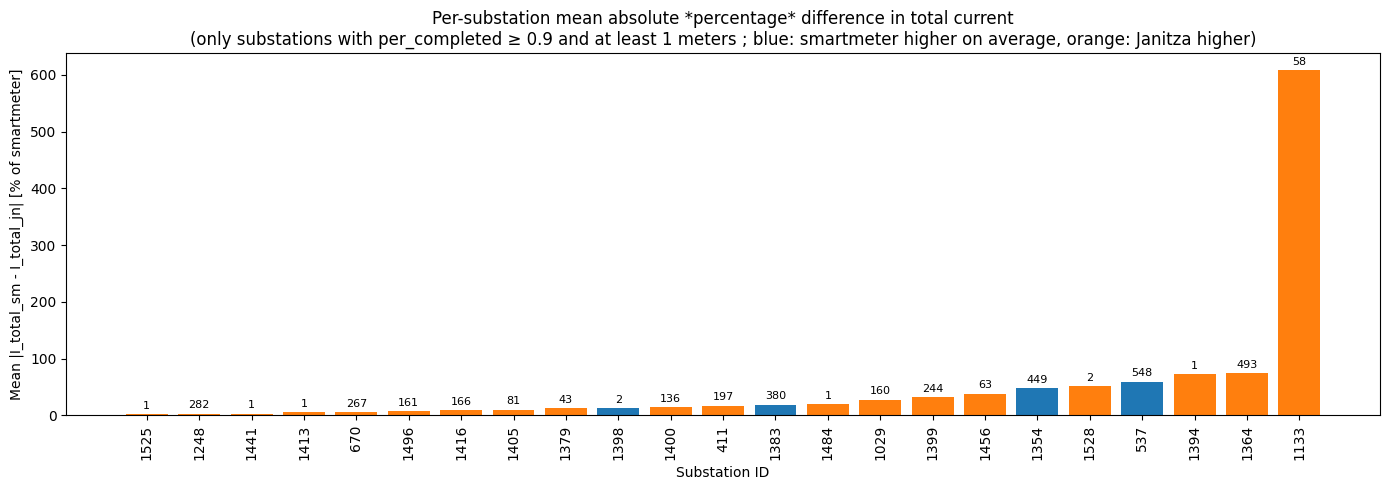

In [190]:
# Work on a copy just to be safe
dfm = df_merged.copy()

# Per-sample absolute percentage diff (NaN if smartmeter current is 0)
dfm["I_total_abs_pct_diff"] = (
    100 * dfm["I_total_diff"].abs() / dfm["I_total_sm"].replace(0, np.nan)
)

# ---- Per-substation statistics in ONE groupby ----
sub_stats = (
    dfm
    .groupby("substation_id")
    .agg(
        mean_I_total_sm   = ("I_total_sm", "mean"),
        mean_I_total_jn   = ("I_total_jn", "mean"),
        mean_diff         = ("I_total_diff", "mean"),
        mean_abs_diff     = ("I_total_diff", lambda s: s.abs().mean()),
        mean_abs_pct_diff = ("I_total_abs_pct_diff", "mean"),
        per_completed     = ("per_completed", "max"),
        n_mps             = ("n_mps", "max"),
    )
)

# ---- filters ----
cutoff  = 0.9   # per_completed threshold
min_num = 1     # minimum number of meters

sub_stats_pct = (
    sub_stats
    .query("n_mps >= @min_num and per_completed >= @cutoff")
    .sort_values("mean_abs_pct_diff")
)

print(f"Number of substations with n_mps >= {min_num}: {len(sub_stats.query('n_mps >= @min_num'))}")
print(f"Number of substations with per_completed >= {cutoff}: {len(sub_stats_pct)}")

# ---- plot ----
x          = np.arange(len(sub_stats_pct))
height     = sub_stats_pct["mean_abs_pct_diff"].to_numpy(float)
sign       = sub_stats_pct["mean_diff"].to_numpy(float)
n_mps_vals = sub_stats_pct["n_mps"].to_numpy(int)
colors     = ["tab:blue" if val > 0 else "tab:orange" for val in sign]
subs       = sub_stats_pct.index.astype(int)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x, height, color=colors)

ax.set_xticks(x)
ax.set_xticklabels(subs, rotation=90)
ax.set_xlabel("Substation ID")
ax.set_ylabel("Mean |I_total_sm - I_total_jn| [% of smartmeter]")
ax.set_title(
    f"Per-substation mean absolute *percentage* difference in total current\n"
    f"(only substations with per_completed ≥ {cutoff} and at least {min_num} meters ; "
    f"blue: smartmeter higher on average, orange: Janitza higher)"
)

offset = 0.01 * (height.max() if len(height) else 1.0)
for xi, hi, n in zip(x, height, n_mps_vals):
    ax.text(xi, hi + offset, str(n), ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()


### CT diagnostics: meaning of the returned columns

For each **substation**, `compute_ct_diagnostics` returns one row with the following
diagnostics. The goal is to separate **CT scaling issues** from **missing meters /
unmetered load / other weirdness**.

---

#### Basic regression between SMD and JD

- **`alpha_ls`**  
  Slope of the unconstrained linear regression  
  $
  I_\text{JD} \approx \alpha_\text{ls} \cdot I_\text{SM} + \beta
  $  
  If everything was perfect and fully metered, we’d expect `alpha_ls ≈ 1`.  
  Values > 1 mean JD is typically larger than SMD; < 1 means the opposite.

- **`beta`**  
  Intercept of that regression. Roughly: JD current when SMD current is 0.  
  In a pure scaling (CT) error scenario this should be close to 0.  
  A big `beta` can suggest some “baseline” unmetered load or bias.

- **`r2`**  
  Coefficient of determination (R²) of the regression.  
  Measures how well a *linear* model with slope and intercept explains JD from SMD.
  Values close to 1 mean “JD is basically a straight-line function of SMD”.

- **`corr`**  
  Pearson correlation between `I_total_jn` and `I_total_sm`.  
  This is a pure shape similarity measure (ignores absolute scale).  
  Values close to 1 mean the time profiles look almost identical.

---

#### Ratio JD / SMD over time

These are based on the pointwise ratio  
$
\text{ratio}_t = \frac{I_{\text{JD},t}}{I_{\text{SM},t}}
$
after filtering out very small currents.

- **`ratio_median`**  
  Typical JD/SMD scale factor. If JD is usually about 1.5× SMD,  
  then `ratio_median ≈ 1.5`.

- **`ratio_std`**  
  Variability of the JD/SMD ratio.  
  Small value → ratio is very stable → looks like a fixed scaling factor.  
  Large value → ratio jumps around → likely more than just a CT scale issue.

- **`ratio_min`**  
  Minimum observed JD/SMD. Normally should be ≥ 1 if JD is an upper bound.
  Very small values can indicate timestamps where SMD > JD or bad data.

- **`ratio_p05`**  
  5th percentile of the ratio distribution (a “robust minimum”).  
  Used as a safer lower bound than `ratio_min` so one glitch doesn’t dominate.

---

#### CT scaling estimates

- **`alpha0_through_origin`**  
  Slope of the regression **forced through (0,0)**:  
  $
  \alpha_0 = \frac{\sum x y}{\sum x^2}
  $  
  This is the “best” pure multiplicative factor relating SMD to JD,
  assuming no intercept. Think of this as the raw CT scale estimate.

- **`alpha_ct`**  
  **Physically constrained** CT-like scaling factor.  
  We want a factor `alpha` such that:
  - It’s close to `alpha0_through_origin`, **and**
  - It respects the physical constraint `alpha * I_{sm} ≤ I_JD`.

  To enforce that, we cap `alpha` using the robust lower bound:
  $
    \alpha_\text{ct} = \min(\alpha_0, \text{ratio\_p05})
  $  
  This is the factor you’d use if you want to scale SMD up towards JD
  without letting it overshoot the Janitza readings.

---

#### Coverage and expected scaling

- **`per_completed`**  
  Smart-meter rollout completeness for this substation (0–1).  
  Example: 0.9 means 90% of meters are present in SMD, 10% missing/unmetered.

- **`n_mps`**  
  Number of metering points (smart meters) contributing to this substation.

- **`expected_alpha_from_coverage`**  
  What the JD/SMD ratio would be **if the only issue was missing meters**,  
  assuming missing customers have similar behaviour to the ones we see:
  $
  \text{expected\_alpha} = \frac{1}{\text{per\_completed}}
  $
  Example: per_completed = 0.8 → expected JD/SMD ≈ 1 / 0.8 = 1.25.

- **`alpha_over_expected`**  
  How much larger the CT factor is than what coverage alone would explain:
  $
  \alpha_\text{over\_expected} = \frac{\alpha_\text{ct}}{\text{expected\_alpha}}
  $  
  - ≈ 1 → mismatch can be explained mostly by missing meters.  
  - >> 1 → JD still much bigger than SMD even after accounting for per_completed  
    → strong hint of CT mis-scaling (or some other systematic error).

---

#### Physical consistency

- **`frac_sm_gt_jn`**  
  Fraction of timestamps where `I_total_sm > I_total_jn`.  
  If Janitza really is the “ground truth” upper bound, this should be near 0.  
  High values mean: topology issue, JD under-reading, SMD over-reading, etc.

- **`n_points`**  
  Number of time samples used for this substation **after** filtering out low
  currents. This is the effective sample size for all the stats above.


In [191]:
df_computed = compute_ct_diagnostics(df_merged)
df_computed.head(5)

,substation_id,alpha_ls,beta,r2,corr,alpha_ct,alpha0_through_origin,ratio_min,ratio_p05,ratio_median,ratio_std,per_completed,n_mps,expected_alpha_from_coverage,alpha_over_expected,frac_sm_gt_jn,n_points
0,6,56.178253,5403.149997,0.592835,0.769958,48.952518,61.135433,43.944683,48.952518,62.119446,5.399998,0.667442,287.0,1.498258,32.672960,0.000000,192
1,29,0.810208,7.981944,0.986538,0.993246,0.763522,0.818787,0.614733,0.763522,0.819746,0.040205,0.103448,6.0,9.666667,0.078985,1.000000,192
2,55,0.978608,33.564228,0.990185,0.995080,0.956210,0.996072,0.899287,0.956210,0.990257,0.042060,0.629921,158.0,1.587500,0.602337,0.630208,192
3,74,0.984223,14.751326,0.978478,0.989181,0.967431,1.001422,0.934083,0.967431,1.004529,0.021129,0.461538,6.0,2.166667,0.446507,0.416667,192
4,76,0.733834,-314.157063,0.889700,0.943239,0.423085,0.539320,0.402019,0.423085,0.515490,0.065169,0.388514,112.0,2.573913,0.164374,1.000000,192


If the issue is CT scaling then we expect the dots to be spread around the corrected line

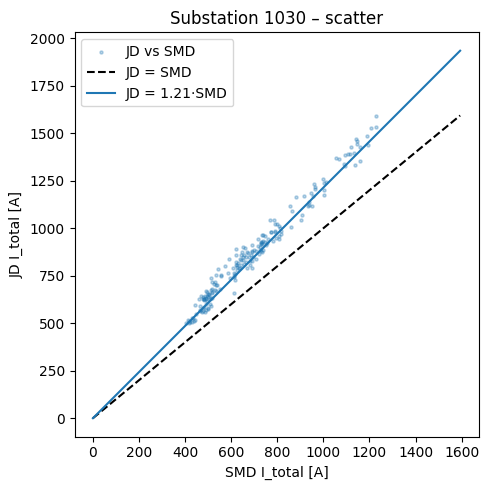

In [203]:
substation_id = 1030
plot_substation_scatter(
    merged=df_merged,
    sid=substation_id,
    alpha=df_computed.loc[df_computed["substation_id"] == substation_id, "alpha_ls"].values[0]
)

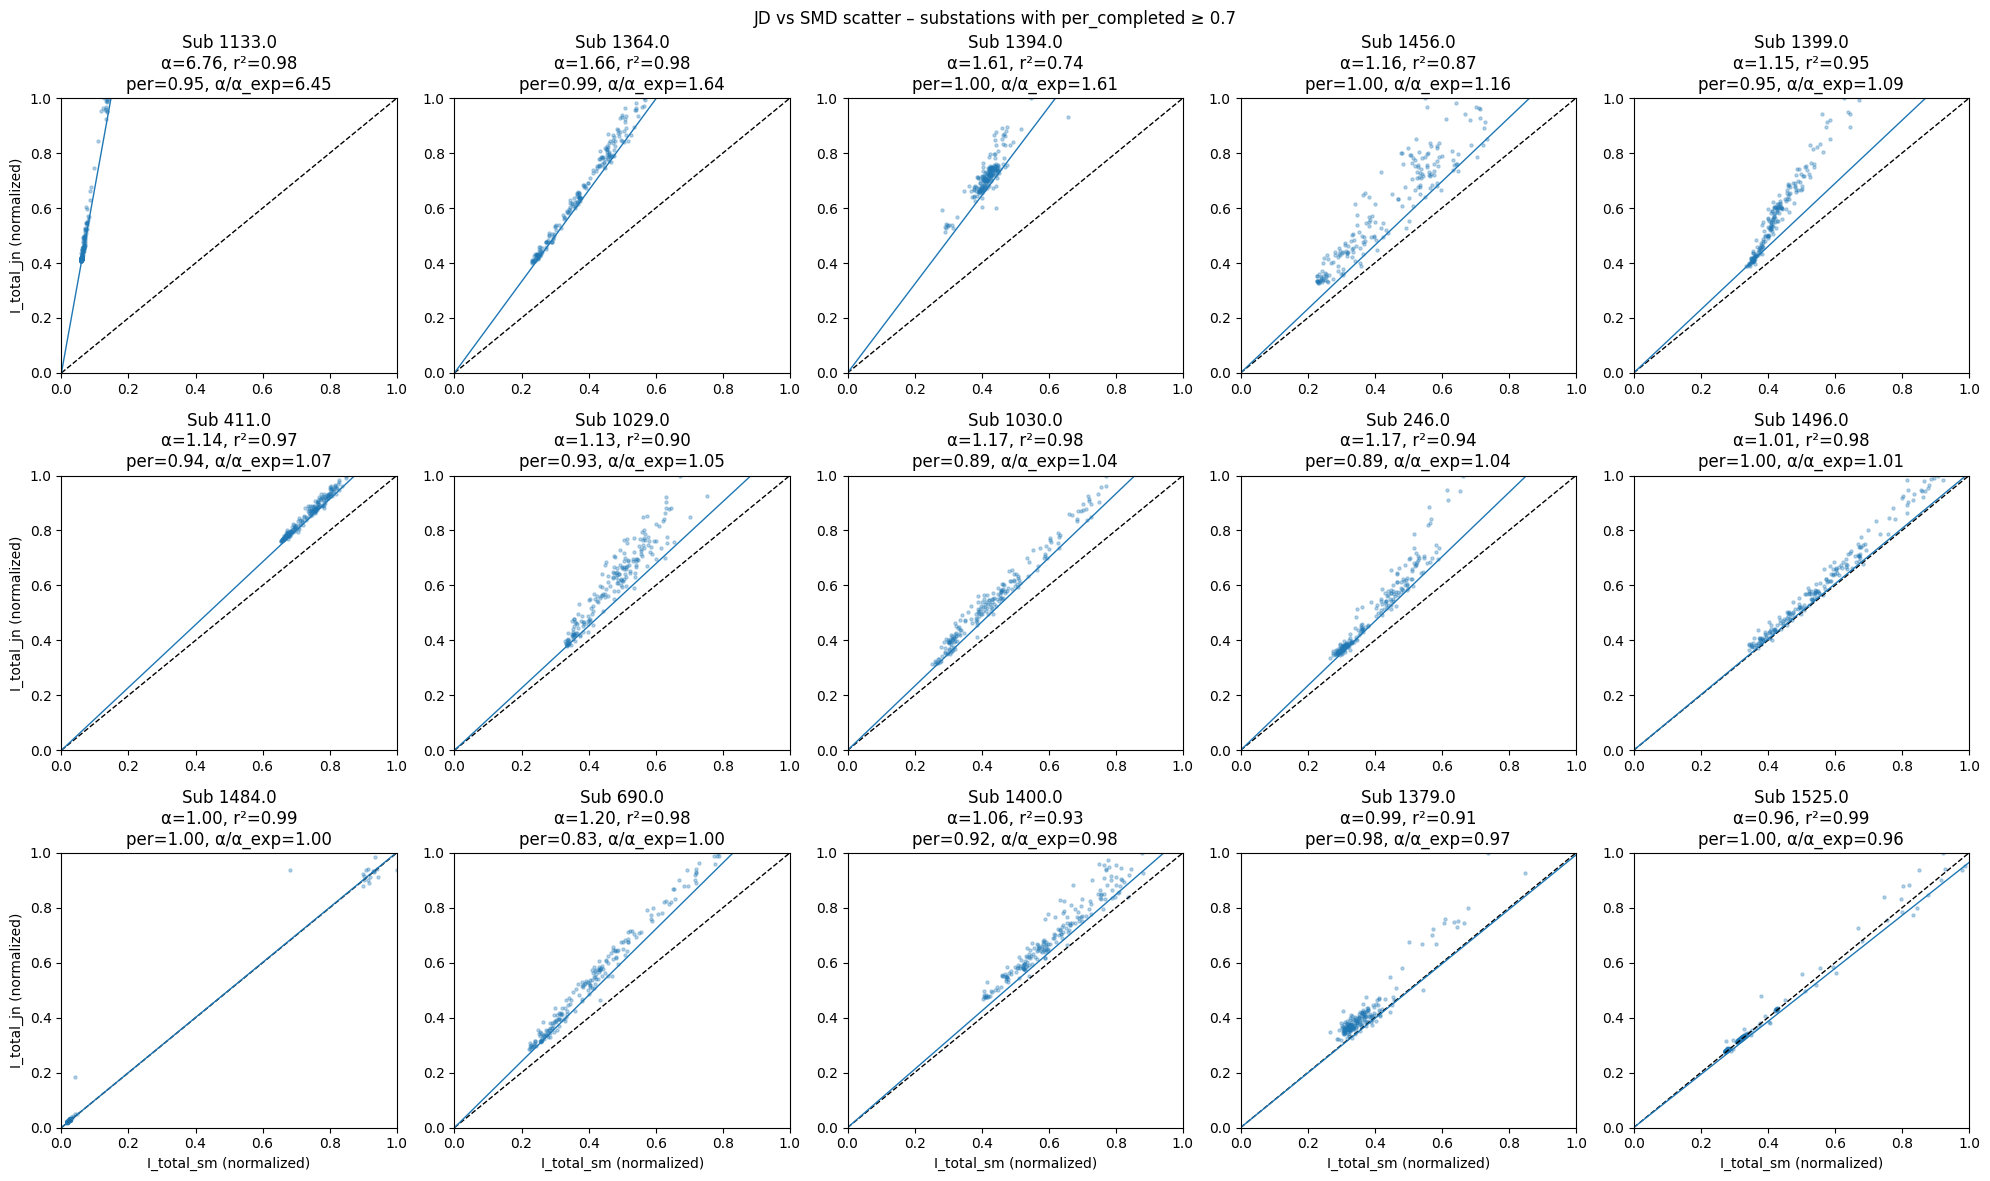

In [193]:
plot_scatter_grid(
    merged=df_merged,
    summary=df_computed,
    min_per_completed=0.7,
    max_plots=15,
    cols=5,
)

Change in the ratio of SMD vs Janitza and after correction

Number of substations with n_mps >= 1: 62
Number of substations with per_completed >= 0.9: 23


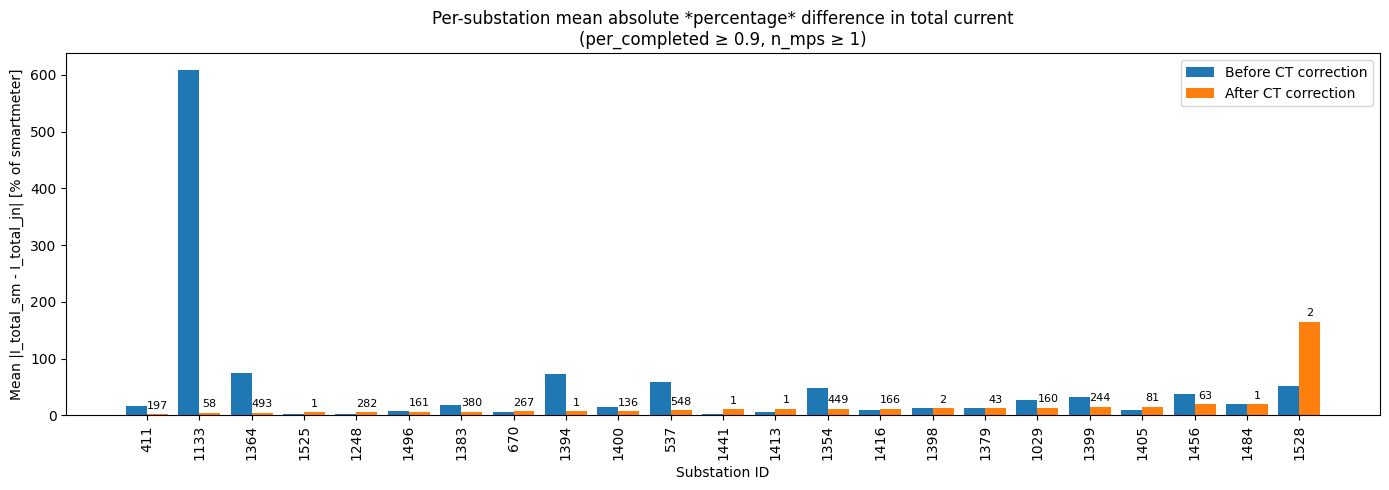

In [194]:

df_before = df_merged.copy()

# per-sample abs % diff (NaN if smartmeter is 0)
df_before["I_total_diff"] = df_before["I_total_sm"] - df_before["I_total_jn"]
df_before["I_total_abs_pct_diff"] = (
    100 * df_before["I_total_diff"].abs() /
    df_before["I_total_sm"].replace(0, np.nan)
)

sub_stats_before = (
    df_before
    .groupby("substation_id")
    .agg(
        mean_I_total_sm   = ("I_total_sm", "mean"),
        mean_I_total_jn   = ("I_total_jn", "mean"),
        mean_diff         = ("I_total_diff", "mean"),
        mean_abs_diff     = ("I_total_diff", lambda s: s.abs().mean()),
        mean_abs_pct_diff = ("I_total_abs_pct_diff", "mean"),
        per_completed     = ("per_completed", "max"),
        n_mps             = ("n_mps", "max"),
    )
)

# --- 2) Apply CT correction: JN_corrected = JN / alpha_ct ---

df_after = df_merged.copy()

# bring alpha_ct per substation onto each sample
df_after = df_after.merge(
    df_computed[["substation_id", "alpha_ct"]],
    on="substation_id",
    how="left",
)

# if some substations don't have alpha_ct, treat as 1.0 (no correction)
df_after["alpha_ct"] = df_after["alpha_ct"].fillna(1.0)

# corrected Janitza total
df_after["I_total_jn_corr"] = df_after["I_total_jn"] / df_after["alpha_ct"]

# corrected diff and abs % diff
df_after["I_total_diff_corr"] = df_after["I_total_sm"] - df_after["I_total_jn_corr"]
df_after["I_total_abs_pct_diff_corr"] = (
    100 * df_after["I_total_diff_corr"].abs() /
    df_after["I_total_sm"].replace(0, np.nan)
)

sub_stats_after = (
    df_after
    .groupby("substation_id")
    .agg(
        mean_I_total_sm        = ("I_total_sm", "mean"),
        mean_I_total_jn_corr   = ("I_total_jn_corr", "mean"),
        mean_diff_corr         = ("I_total_diff_corr", "mean"),
        mean_abs_diff_corr     = ("I_total_diff_corr", lambda s: s.abs().mean()),
        mean_abs_pct_diff_corr = ("I_total_abs_pct_diff_corr", "mean"),
        per_completed          = ("per_completed", "max"),
        n_mps                  = ("n_mps", "max"),
    )
)

# --- 3) Filter substations and combine BEFORE/AFTER stats ---

cutoff  = 0.9  # per_completed threshold
min_num = 1    # minimum number of meters

# keep only subs that pass coverage + meter count, in BOTH tables
mask_before = (sub_stats_before["per_completed"] >= cutoff) & (sub_stats_before["n_mps"] >= min_num)
mask_after  = (sub_stats_after["per_completed"]  >= cutoff) & (sub_stats_after["n_mps"]  >= min_num)

valid_ids = sub_stats_before.index[mask_before & mask_after]

combined = pd.DataFrame(index=valid_ids)
combined["mean_abs_pct_before"] = sub_stats_before.loc[valid_ids, "mean_abs_pct_diff"]
combined["mean_abs_pct_after"]  = sub_stats_after.loc[valid_ids, "mean_abs_pct_diff_corr"]
combined["mean_diff_after"]     = sub_stats_after.loc[valid_ids, "mean_diff_corr"]
combined["n_mps"]               = sub_stats_after.loc[valid_ids, "n_mps"]

# sort e.g. by corrected error
combined = combined.sort_values("mean_abs_pct_after")

print(f"Number of substations with n_mps >= {min_num}: {len(sub_stats_before.query('n_mps >= @min_num'))}")
print(f"Number of substations with per_completed >= {cutoff}: {len(combined)}")

# --- 4) Plot BEFORE vs AFTER as side-by-side bars ---

x      = np.arange(len(combined))
width  = 0.4

before = combined["mean_abs_pct_before"].to_numpy(float)
after  = combined["mean_abs_pct_after"].to_numpy(float)
n_mps_vals = combined["n_mps"].to_numpy(int)
subs   = combined.index.astype(int)

fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(x - width/2, before, width=width, label="Before CT correction")
ax.bar(x + width/2, after,  width=width, label="After CT correction")

ax.set_xticks(x)
ax.set_xticklabels(subs, rotation=90)
ax.set_xlabel("Substation ID")
ax.set_ylabel("Mean |I_total_sm - I_total_jn| [% of smartmeter]")
ax.set_title(
    "Per-substation mean absolute *percentage* difference in total current\n"
    f"(per_completed ≥ {cutoff}, n_mps ≥ {min_num})"
)

# add n_mps labels above AFTER bars
offset = 0.01 * (max(before.max(), after.max()) if len(before) else 1.0)
for xi, hi, n in zip(x, after, n_mps_vals):
    ax.text(
        xi + width/2,
        hi + offset,
        str(n),
        ha="center",
        va="bottom",
        fontsize=8,
    )

ax.legend()
plt.tight_layout()
plt.show()


Number of substations with n_mps >= 1: 62
Number of substations with per_completed >= 0.9: 23


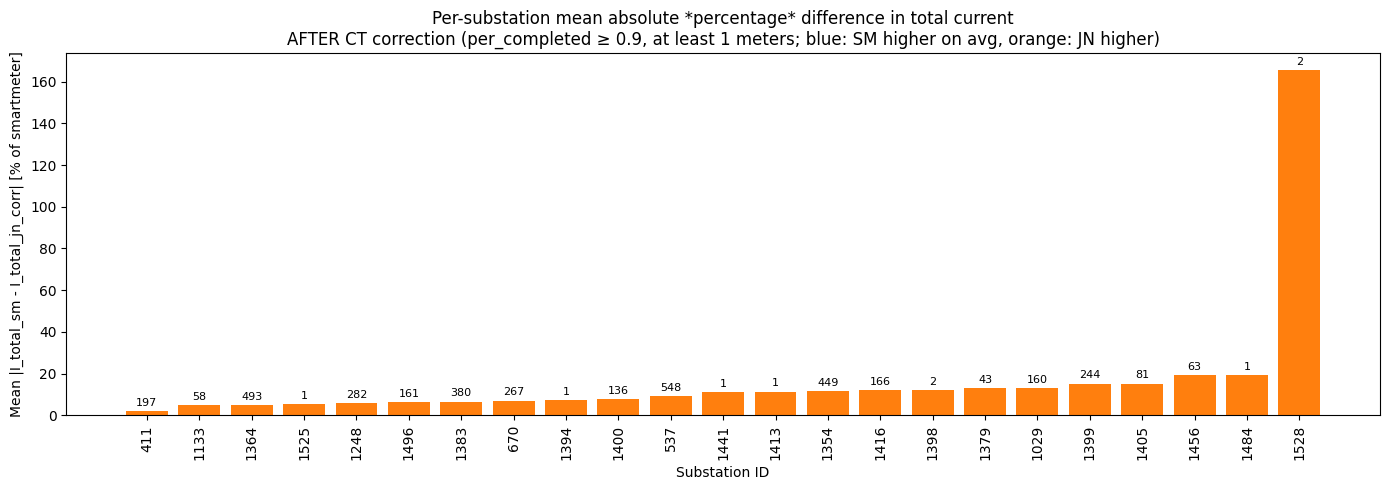

In [195]:
# --- 1) Apply CT correction to Janitza in a copy of df_merged ---

dfc = df_merged.copy()

# Bring alpha_ct from df_computed (or summary) – must have columns: substation_id, alpha_ct
dfc = dfc.merge(
    df_computed[["substation_id", "alpha_ct"]],
    on="substation_id",
    how="left",
)

# If some substations don't have alpha_ct, treat them as "no correction"
dfc["alpha_ct"] = dfc["alpha_ct"].fillna(1.0)

# ASSUMPTION: you fitted JD ≈ alpha_ct * SMD
# → to correct Janitza to smartmeter scale, divide by alpha_ct:
dfc["I_total_jn_corr"] = dfc["I_total_jn"] / dfc["alpha_ct"]

# Diff and abs % diff AFTER correction
dfc["I_total_diff_corr"] = dfc["I_total_sm"] - dfc["I_total_jn_corr"]
dfc["I_total_abs_pct_diff_corr"] = (
    100 * dfc["I_total_diff_corr"].abs() / dfc["I_total_sm"].replace(0, np.nan)
)

# --- 2) Per-substation stats (same structure as before, but corrected) ---

sub_stats_corr = (
    dfc
    .groupby("substation_id")
    .agg(
        mean_I_total_sm        = ("I_total_sm", "mean"),
        mean_I_total_jn_corr   = ("I_total_jn_corr", "mean"),
        mean_diff_corr         = ("I_total_diff_corr", "mean"),
        mean_abs_diff_corr     = ("I_total_diff_corr", lambda s: s.abs().mean()),
        mean_abs_pct_diff_corr = ("I_total_abs_pct_diff_corr", "mean"),
        per_completed          = ("per_completed", "max"),
        n_mps                  = ("n_mps", "max"),
    )
)

# --- 3) Filter + sort like before, but using corrected metric ---

cutoff  = 0.9   # per_completed threshold
min_num = 1     # minimum number of meters

sub_stats_pct_corr = (
    sub_stats_corr
    .query("n_mps >= @min_num and per_completed >= @cutoff")
    .sort_values("mean_abs_pct_diff_corr")
)

print(f"Number of substations with n_mps >= {min_num}: {len(sub_stats_corr.query('n_mps >= @min_num'))}")
print(f"Number of substations with per_completed >= {cutoff}: {len(sub_stats_pct_corr)}")

# --- 4) Plot corrected mean abs % diff per substation ---

x          = np.arange(len(sub_stats_pct_corr))
height     = sub_stats_pct_corr["mean_abs_pct_diff_corr"].to_numpy(float)
sign       = sub_stats_pct_corr["mean_diff_corr"].to_numpy(float)
n_mps_vals = sub_stats_pct_corr["n_mps"].to_numpy(int)
colors     = ["tab:blue" if val > 0 else "tab:orange" for val in sign]
subs       = sub_stats_pct_corr.index.astype(int)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x, height, color=colors)

ax.set_xticks(x)
ax.set_xticklabels(subs, rotation=90)
ax.set_xlabel("Substation ID")
ax.set_ylabel("Mean |I_total_sm - I_total_jn_corr| [% of smartmeter]")
ax.set_title(
    "Per-substation mean absolute *percentage* difference in total current\n"
    f"AFTER CT correction (per_completed ≥ {cutoff}, at least {min_num} meters; "
    "blue: SM higher on avg, orange: JN higher)"
)

offset = 0.01 * (height.max() if len(height) else 1.0)
for xi, hi, n in zip(x, height, n_mps_vals):
    ax.text(xi, hi + offset, str(n), ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()


Ratio can be misleading here are stations ploted with old smart meter current and corrected.

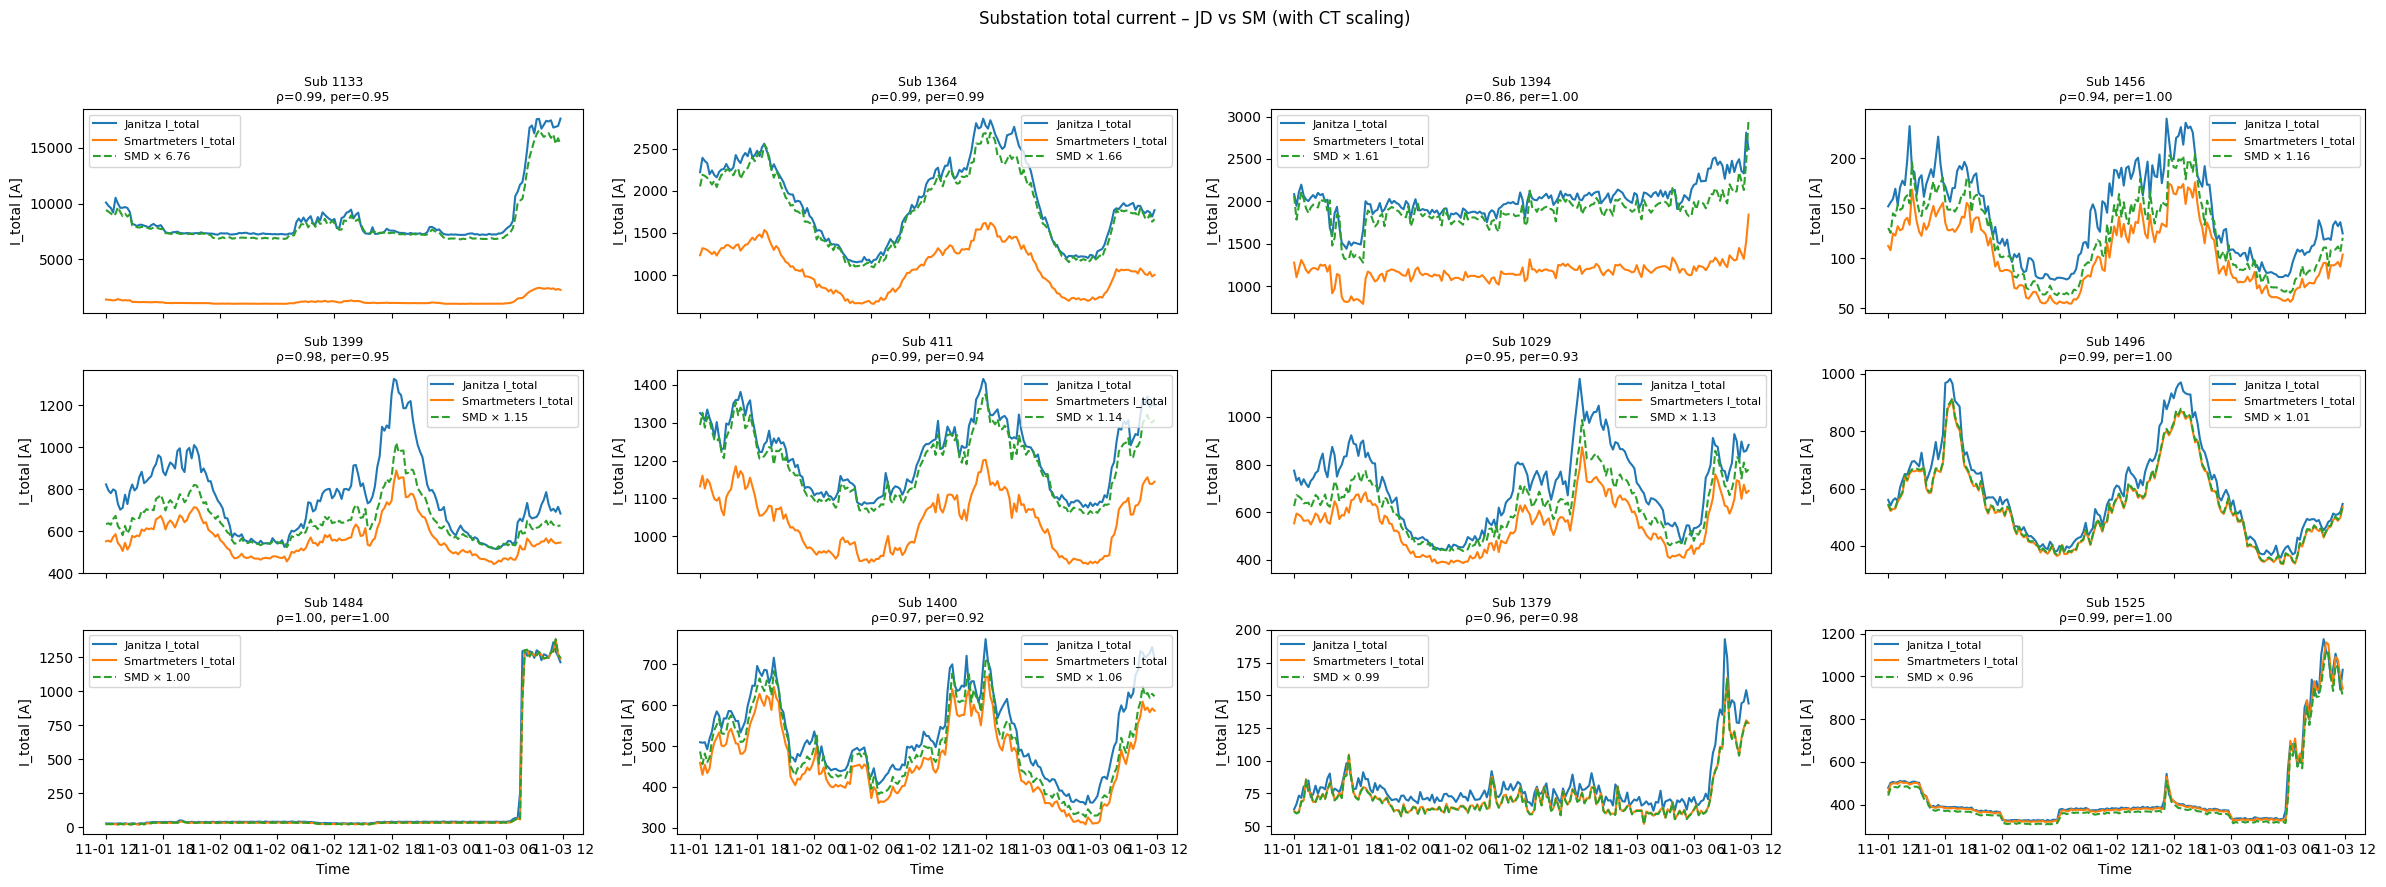

In [196]:

def plot_substation_timeseries_grid(
    merged: pd.DataFrame,
    summary: pd.DataFrame,
    substation_ids=None,
    min_per_completed: float = 0.7,
    max_plots: int = 12,
    cols: int = 4,
    max_points: int = 2000,
):
    """
    Grid of time series plots per substation.

    For each substation:
      - plots Janitza I_total_jn
      - plots Smartmeter I_total_sm
      - if alpha_ct is available in `summary`, also plots alpha_ct * I_total_sm

    Each subplot has its own y-axis scale (no shared y), but x (time) is shared.
    """

    # --- choose which substations to plot ---
    if substation_ids is not None:
        # Use explicit list, limited to max_plots
        sids = list(substation_ids)[:max_plots]
        cand = summary[summary["substation_id"].isin(sids)].copy()
    else:
        # Use summary to pick "interesting" substations
        cand = summary[summary["per_completed"] >= min_per_completed].copy()

        # Sort by alpha_over_expected if available, else by substation_id
        if "alpha_over_expected" in cand.columns:
            cand = cand.sort_values("alpha_over_expected", ascending=False)
        else:
            cand = cand.sort_values("substation_id")

        cand = cand.head(max_plots)
        sids = cand["substation_id"].tolist()

    if not sids:
        print("No substations to plot (check filters or substation_ids).")
        return

    # Make it easy to look up per-substation diagnostics
    summary_idx = summary.set_index("substation_id")

    # --- create grid of subplots ---
    n_plots = len(sids)
    rows = math.ceil(n_plots / cols)

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(6 * cols, 3 * rows),
        sharex=True,
        sharey=False,  # <<< each substation has its own y-scale
    )
    axes = np.array(axes).reshape(-1)

    for ax, sid in zip(axes, sids):
        g = merged[merged["substation_id"] == sid].sort_values("ts")

        if g.empty:
            ax.set_visible(False)
            continue

        if len(g) > max_points:
            g = g.iloc[:max_points]

        # Get alpha_ct if present
        alpha = None
        if "alpha_ct" in summary_idx.columns and sid in summary_idx.index:
            alpha_val = summary_idx.loc[sid, "alpha_ct"]
            try:
                alpha = float(alpha_val)
            except Exception:
                alpha = None

        # Plot original currents
        ax.plot(g["ts"], g["I_total_jn"], label="Janitza I_total")
        ax.plot(g["ts"], g["I_total_sm"], label="Smartmeters I_total")

        # Optional CT-scaled smartmeter line
        if alpha is not None and np.isfinite(alpha):
            ax.plot(g["ts"], alpha * g["I_total_sm"], "--", label=f"SMD × {alpha:.2f}")

        # Build a small informative title
        title = f"Sub {sid}"
        if "corr" in summary_idx.columns and sid in summary_idx.index:
            corr = summary_idx.loc[sid, "corr"]
            try:
                title += f"\nρ={corr:.2f}"
            except Exception:
                pass
        if "per_completed" in summary_idx.columns and sid in summary_idx.index:
            per = summary_idx.loc[sid, "per_completed"]
            try:
                title += f", per={per:.2f}"
            except Exception:
                pass

        ax.set_title(title, fontsize=9)
        ax.set_ylabel("I_total [A]")
        ax.legend(fontsize=8)

    # Hide unused axes
    for ax in axes[n_plots:]:
        ax.set_visible(False)

    # x-label only on bottom row
    for i, ax in enumerate(axes[:n_plots]):
        row_idx = i // cols
        if row_idx == rows - 1:
            ax.set_xlabel("Time")

    fig.suptitle("Substation total current – JD vs SM (with CT scaling)", y=0.98)
    plt.tight_layout(rect=(0, 0, 1, 0.96))
    plt.show()


# Using your existing dfs:
# df_merged: merged current data
# df_computed: output from compute_ct_diagnostics(df_merged)

# Option 1: automatically pick “interesting” substations (by per_completed / alpha_over_expected)
plot_substation_timeseries_grid(
    merged=df_merged,
    summary=df_computed,
    min_per_completed=0.9,
    max_plots=12,
    cols=4,
    max_points=3000,
)



Lets see the affect on power

In [197]:
# Paths assuming notebook is in src/phasebalance
sm_path_power = "../data/smartmeter_15min_all_from_devices_20251101_20251103_power.parquet"
jn_path_power = "../data/janitza_3phase_P_all_20251101_1200_20251103_1200.parquet"

df_sm_power = pd.read_parquet(sm_path_power)
df_jn_power = pd.read_parquet(jn_path_power)

# Add substation_id column by parsing dnr_str
df_jn_power["substation_id"] = df_jn_power["dnr_str"].map(parse_dnr)
df_sm_power = df_sm_power.sort_values(["substation_id", "ts"])
df_jn_power = df_jn_power.sort_values(["substation_id", "ts"])

df_sm_power = df_sm_power.rename(columns={"I_a" : "P_a", "I_b": "P_b", "I_c": "P_c", "I_total": "P_total"})

# Ensure timestamps are timezone-naive UTC
df_jn_power["ts"] = pd.to_datetime(df_jn_power["ts"], utc=True).dt.tz_localize(None)


# Get the substations that exist in JN
jn_substations = df_jn_power["substation_id"].unique()

# Filter SM to only keep those substations
df_sm_power = df_sm_power[df_sm_power["substation_id"].isin(jn_substations)].copy()


# Make sure timestamps are the same dtype
df_sm_power["ts"] = pd.to_datetime(df_sm_power["ts"])
df_jn_power["ts"] = pd.to_datetime(df_jn_power["ts"])

# Correct Janitza timestamps to match Smartmeter timestamps
df_jn_power["ts"]= df_jn_power["ts"].dt.ceil("10min") 

# Trim both datasets to the same time range
max_ts_sm = df_sm_power["ts"].max()
df_sm_power = df_sm_power[df_sm_power["ts"] < max_ts_sm].copy()
df_jn_power = df_jn_power[df_jn_power["ts"] < max_ts_sm].copy()

# Remove weird substations from both datasets
weird_ids = [1482, 1534, 1554,1049,710]
df_sm_power = df_sm_power[~df_sm_power["substation_id"].isin(weird_ids)].copy()
df_jn_power = df_jn_power[~df_jn_power["substation_id"].isin(weird_ids)].copy()

# drop duplicates in Janitza data
df_jn_power = df_jn_power.drop_duplicates(subset=["substation_id", "ts"], keep="first").copy()


df_merged_power = df_sm_power.merge(
    df_jn_power,
    on=["substation_id", "ts"],
    how="inner",             # intersection only
    suffixes=("_sm", "_jn"),
    validate="one_to_one"    # safety check: raises if keys aren't 1:1
)
for col in ["P_a", "P_b", "P_c", "P_total"]:
    df_merged_power[f"{col}_diff"] = df_merged_power[f"{col}_sm"] - df_merged_power[f"{col}_jn"]

df_merged_power[["P_a_diff", "P_b_diff", "P_c_diff", "P_total_diff"]].describe()
print("SM shape:",df_sm_power.shape)
print("JN shape:",df_jn_power.shape)
print("Merged shape:",df_merged_power.shape)

SM shape: (16992, 8)
JN shape: (17278, 7)
Merged shape: (16990, 17)


We assume for each substation that Janitza and smartmeter power are related by

* Model (before correction):
  $P_{\text{JN}} = \alpha_{\text{CT}} \cdot P_{\text{SM}}$


Number of substations with n_mps >= 1: 59
Number of substations with per_completed >= 0.9: 23


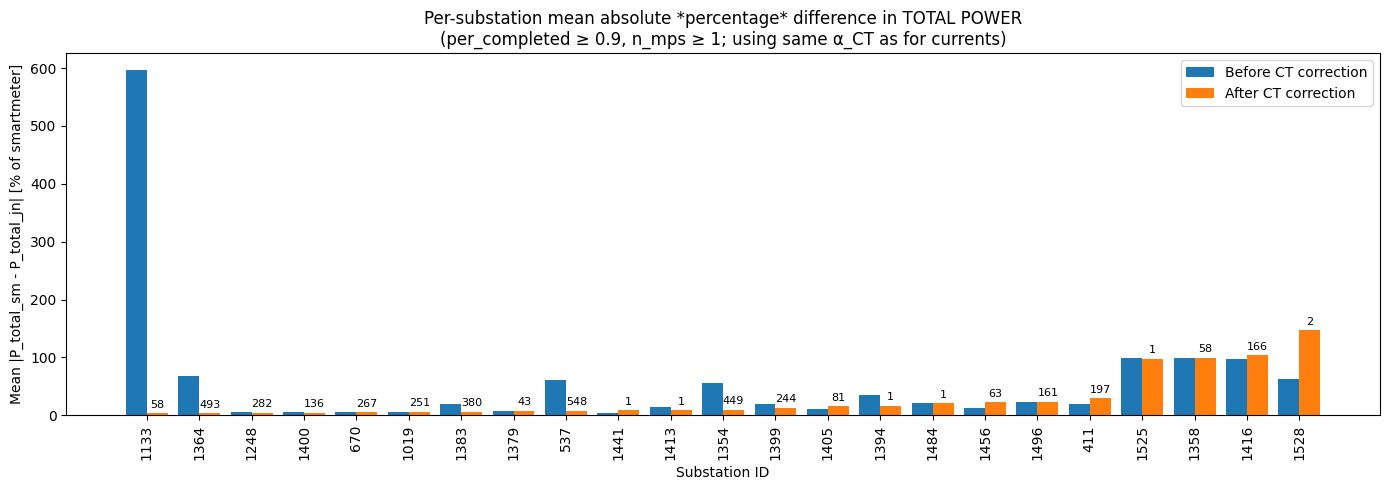

In [198]:
# --- 1) BEFORE: power diffs without CT correction ---

df_power_before = df_merged_power.copy()

# Total power diff and abs % diff (NaN if smartmeter P_total is 0)
df_power_before["P_total_diff"] = (
    df_power_before["P_total_sm"] - df_power_before["P_total_jn"]
)
df_power_before["P_total_abs_pct_diff"] = (
    100 * df_power_before["P_total_diff"].abs()
    / df_power_before["P_total_sm"].replace(0, np.nan)
)

sub_stats_power_before = (
    df_power_before
    .groupby("substation_id")
    .agg(
        mean_P_total_sm   = ("P_total_sm", "mean"),
        mean_P_total_jn   = ("P_total_jn", "mean"),
        mean_diff         = ("P_total_diff", "mean"),
        mean_abs_diff     = ("P_total_diff", lambda s: s.abs().mean()),
        mean_abs_pct_diff = ("P_total_abs_pct_diff", "mean"),
        per_completed     = ("per_completed", "max"),
        n_mps             = ("n_mps", "max"),
    )
)

# --- 2) AFTER: apply CT scaling alpha_ct to Janitza power ---

df_power_after = df_merged_power.copy()

# bring alpha_ct per substation
df_power_after = df_power_after.merge(
    df_computed[["substation_id", "alpha_ct"]],
    on="substation_id",
    how="left",
)

# substations without alpha_ct → no correction
df_power_after["alpha_ct"] = df_power_after["alpha_ct"].fillna(1.0)

# ASSUMPTION: JD ≈ alpha_ct * SM  ⇒  correct JN by dividing by alpha_ct
df_power_after["P_total_jn_corr"] = (
    df_power_after["P_total_jn"] / df_power_after["alpha_ct"]
)

# corrected diff and abs % diff
df_power_after["P_total_diff_corr"] = (
    df_power_after["P_total_sm"] - df_power_after["P_total_jn_corr"]
)
df_power_after["P_total_abs_pct_diff_corr"] = (
    100 * df_power_after["P_total_diff_corr"].abs()
    / df_power_after["P_total_sm"].replace(0, np.nan)
)

sub_stats_power_after = (
    df_power_after
    .groupby("substation_id")
    .agg(
        mean_P_total_sm        = ("P_total_sm", "mean"),
        mean_P_total_jn_corr   = ("P_total_jn_corr", "mean"),
        mean_diff_corr         = ("P_total_diff_corr", "mean"),
        mean_abs_diff_corr     = ("P_total_diff_corr", lambda s: s.abs().mean()),
        mean_abs_pct_diff_corr = ("P_total_abs_pct_diff_corr", "mean"),
        per_completed          = ("per_completed", "max"),
        n_mps                  = ("n_mps", "max"),
    )
)

# --- 3) Filter substations and align BEFORE/AFTER ---

cutoff  = 0.9   # per_completed threshold
min_num = 1     # minimum number of meters

mask_before = (
    (sub_stats_power_before["per_completed"] >= cutoff)
    & (sub_stats_power_before["n_mps"] >= min_num)
)
mask_after = (
    (sub_stats_power_after["per_completed"] >= cutoff)
    & (sub_stats_power_after["n_mps"] >= min_num)
)

valid_ids = sub_stats_power_before.index[mask_before & mask_after]

combined_p = pd.DataFrame(index=valid_ids)
combined_p["mean_abs_pct_before"] = sub_stats_power_before.loc[valid_ids, "mean_abs_pct_diff"]
combined_p["mean_abs_pct_after"]  = sub_stats_power_after.loc[valid_ids, "mean_abs_pct_diff_corr"]
combined_p["n_mps"]               = sub_stats_power_after.loc[valid_ids, "n_mps"]

# sort by corrected error
combined_p = combined_p.sort_values("mean_abs_pct_after")

print(f"Number of substations with n_mps >= {min_num}: {len(sub_stats_power_before.query('n_mps >= @min_num'))}")
print(f"Number of substations with per_completed >= {cutoff}: {len(combined_p)}")

# --- 4) Plot BEFORE vs AFTER (power) ---

x      = np.arange(len(combined_p))
width  = 0.4

before = combined_p["mean_abs_pct_before"].to_numpy(float)
after  = combined_p["mean_abs_pct_after"].to_numpy(float)
n_mps_vals = combined_p["n_mps"].to_numpy(int)
subs   = combined_p.index.astype(int)

fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(x - width/2, before, width=width, label="Before CT correction")
ax.bar(x + width/2, after,  width=width, label="After CT correction")

ax.set_xticks(x)
ax.set_xticklabels(subs, rotation=90)
ax.set_xlabel("Substation ID")
ax.set_ylabel("Mean |P_total_sm - P_total_jn| [% of smartmeter]")
ax.set_title(
    "Per-substation mean absolute *percentage* difference in TOTAL POWER\n"
    f"(per_completed ≥ {cutoff}, n_mps ≥ {min_num}; using same α_CT as for currents)"
)

offset = 0.01 * (max(before.max(), after.max()) if len(before) else 1.0)
for xi, hi, n in zip(x, after, n_mps_vals):
    ax.text(
        xi + width/2,
        hi + offset,
        str(n),
        ha="center",
        va="bottom",
        fontsize=8,
    )

ax.legend()
plt.tight_layout()
plt.show()


Number of substations with n_mps >= {min_num}: 59
Number of substations with per_completed >= {cutoff}: 23


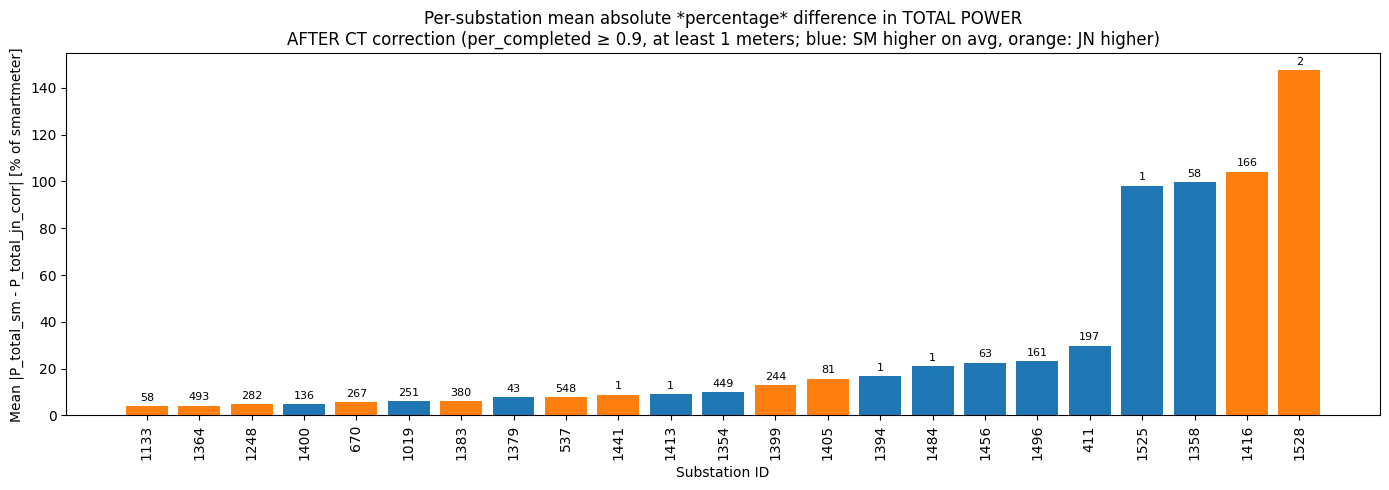

In [199]:
# --- 1) Apply CT correction to Janitza POWER in a copy of df_merged_power ---

dfp = df_merged_power.copy()

# Bring alpha_ct from df_computed – must have columns: substation_id, alpha_ct
dfp = dfp.merge(
    df_computed[["substation_id", "alpha_ct"]],
    on="substation_id",
    how="left",
)

# If some substations don't have alpha_ct, treat them as "no correction"
dfp["alpha_ct"] = dfp["alpha_ct"].fillna(1.0)

# ASSUMPTION: you fitted JD ≈ alpha_ct * SMD
# → to correct Janitza to smartmeter scale, divide by alpha_ct:
dfp["P_total_jn_corr"] = dfp["P_total_jn"] / dfp["alpha_ct"]

# Diff and abs % diff AFTER correction
dfp["P_total_diff_corr"] = dfp["P_total_sm"] - dfp["P_total_jn_corr"]
dfp["P_total_abs_pct_diff_corr"] = (
    100 * dfp["P_total_diff_corr"].abs() / dfp["P_total_sm"].replace(0, np.nan)
)

# --- 2) Per-substation stats (same structure as before, but for POWER) ---

sub_stats_power_corr = (
    dfp
    .groupby("substation_id")
    .agg(
        mean_P_total_sm        = ("P_total_sm", "mean"),
        mean_P_total_jn_corr   = ("P_total_jn_corr", "mean"),
        mean_diff_corr         = ("P_total_diff_corr", "mean"),
        mean_abs_diff_corr     = ("P_total_diff_corr", lambda s: s.abs().mean()),
        mean_abs_pct_diff_corr = ("P_total_abs_pct_diff_corr", "mean"),
        per_completed          = ("per_completed", "max"),
        n_mps                  = ("n_mps", "max"),
    )
)

# --- 3) Filter + sort like before, but using corrected POWER metric ---

cutoff  = 0.9   # per_completed threshold
min_num = 1     # minimum number of meters

sub_stats_pct_power_corr = (
    sub_stats_power_corr
    .query("n_mps >= @min_num and per_completed >= @cutoff")
    .sort_values("mean_abs_pct_diff_corr")
)

print("Number of substations with n_mps >= {min_num}:",
      len(sub_stats_power_corr.query("n_mps >= @min_num")))
print("Number of substations with per_completed >= {cutoff}:",
      len(sub_stats_pct_power_corr))

# --- 4) Plot corrected mean abs % diff per substation (POWER) ---

x          = np.arange(len(sub_stats_pct_power_corr))
height     = sub_stats_pct_power_corr["mean_abs_pct_diff_corr"].to_numpy(float)
sign       = sub_stats_pct_power_corr["mean_diff_corr"].to_numpy(float)
n_mps_vals = sub_stats_pct_power_corr["n_mps"].to_numpy(int)
colors     = ["tab:blue" if val > 0 else "tab:orange" for val in sign]
subs       = sub_stats_pct_power_corr.index.astype(int)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x, height, color=colors)

ax.set_xticks(x)
ax.set_xticklabels(subs, rotation=90)
ax.set_xlabel("Substation ID")
ax.set_ylabel("Mean |P_total_sm - P_total_jn_corr| [% of smartmeter]")
ax.set_title(
    "Per-substation mean absolute *percentage* difference in TOTAL POWER\n"
    f"AFTER CT correction (per_completed ≥ {cutoff}, at least {min_num} meters; "
    "blue: SM higher on avg, orange: JN higher)"
)

offset = 0.01 * (height.max() if len(height) else 1.0)
for xi, hi, n in zip(x, height, n_mps_vals):
    ax.text(xi, hi + offset, str(n), ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()


Now we can look at the voltage

In [200]:
SM_voltage = "../data/smartmeter_15min_all_from_devices_20251101_20251103_voltage.parquet"  # smartmeter voltage
df_sm_voltage = pd.read_parquet(SM_voltage)

J_voltage = "../data/janitza_3phase_V_all_20251101_1200_20251103_1200.parquet"  # Janitza voltage
df_J_voltage = pd.read_parquet(J_voltage)

# Add substation_id column by parsing dnr_str
df_J_voltage["substation_id"] = df_J_voltage["dnr_str"].map(parse_dnr)
df_sm_voltage = df_sm_voltage.sort_values(["substation_id", "ts"])
df_J_voltage = df_J_voltage.sort_values(["substation_id", "ts"])

df_sm_voltage = df_sm_voltage.rename(columns={"I_a" : "P_a", "I_b": "P_b", "I_c": "P_c", "I_total": "P_total"})

# Ensure timestamps are timezone-naive UTC
df_J_voltage["ts"] = pd.to_datetime(df_J_voltage["ts"], utc=True).dt.tz_localize(None)


# Get the substations that exist in JN
jn_substations = df_J_voltage["substation_id"].unique()

# Filter SM to only keep those substations
df_sm_voltage = df_sm_voltage[df_sm_voltage["substation_id"].isin(jn_substations)].copy()


# Make sure timestamps are the same dtype
df_sm_voltage["ts"] = pd.to_datetime(df_sm_voltage["ts"])
df_J_voltage["ts"] = pd.to_datetime(df_J_voltage["ts"])

# Correct Janitza timestamps to match Smartmeter timestamps
df_J_voltage["ts"]= df_J_voltage["ts"].dt.ceil("10min") 

# Trim both datasets to the same time range
max_ts_sm = df_sm_voltage["ts"].max()
df_sm_voltage = df_sm_voltage[df_sm_voltage["ts"] < max_ts_sm].copy()
df_J_voltage = df_J_voltage[df_J_voltage["ts"] < max_ts_sm].copy()

# Remove weird substations from both datasets
weird_ids = [1482, 1534, 1554,1049,710]
df_sm_voltage = df_sm_voltage[~df_sm_voltage["substation_id"].isin(weird_ids)].copy()
df_J_voltage = df_J_voltage[~df_J_voltage["substation_id"].isin(weird_ids)].copy()

# drop duplicates in Janitza data
df_J_voltage = df_J_voltage.drop_duplicates(subset=["substation_id", "ts"], keep="first").copy()


df_merged_voltage = df_sm_voltage.merge(
    df_J_voltage,
    on=["substation_id", "ts"],
    how="inner",             # intersection only
    suffixes=("_sm", "_jn"),
    validate="one_to_one"    # safety check: raises if keys aren't 1:1
)

print("SM shape:",df_sm_voltage.shape)
print("JN shape:",df_J_voltage.shape)
print("Merged shape:",df_merged_voltage.shape)

SM shape: (18144, 6)
JN shape: (18411, 6)
Merged shape: (18123, 10)


Voltage corr

In [201]:
def compute_voltage_corr(df_v, min_points: int = 20) -> pd.DataFrame:
    rows = []
    for sid, g in df_v.groupby("substation_id"):
        g = g.dropna(subset=["V_mean_jn", "V_mean_sm"])
        if len(g) < min_points:
            continue
        corr = g["V_mean_jn"].corr(g["V_mean_sm"])
        rows.append({
            "substation_id": sid,
            "V_corr": corr,
            "n_points": len(g),
        })
    return pd.DataFrame(rows)


df_merged_voltage["V_mean_jn"] = df_merged_voltage[["V_a_jn", "V_b_jn", "V_c_jn"]].mean(axis=1)
df_merged_voltage["V_mean_sm"] = df_merged_voltage[["V_a_sm", "V_b_sm", "V_c_sm"]].mean(axis=1)

voltage_corr_summary = compute_voltage_corr(df_merged_voltage)
voltage_corr_summary.sort_values("V_corr", ascending=False).head(30)


,substation_id,V_corr,n_points
52,1418,0.999488,287
4,76,0.993815,284
50,1413,0.981005,288
60,1528,0.980363,288
36,1354,0.980345,288
42,1383,0.979006,288
57,1496,0.978100,288
45,1396,0.977857,288
6,176,0.976601,288
3,74,0.976155,288


In [202]:
print("Janitza global time range:")
print("  first:", df_jn_power["ts"].min())
print("  last :", df_jn_power["ts"].max())

print("Smartmeter global time range:")
print("  first:", df_sm_power["ts"].min())
print("  last :", df_sm_power["ts"].max())

print("\nJanitza per-substation time ranges:")
print(
    df_jn_power
      .groupby("substation_id")["ts"]
      .agg(["min", "max", "nunique"])
)


Janitza global time range:
  first: 2025-11-01 12:00:00
  last : 2025-11-03 11:50:00
Smartmeter global time range:
  first: 2025-11-01 12:00:00
  last : 2025-11-03 11:50:00

Janitza per-substation time ranges:
                              min                 max  nunique
substation_id                                                 
6             2025-11-01 12:00:00 2025-11-03 11:50:00      288
29            2025-11-01 12:00:00 2025-11-03 11:50:00      288
55            2025-11-01 12:00:00 2025-11-03 11:50:00      288
74            2025-11-01 12:00:00 2025-11-03 11:50:00      288
76            2025-11-01 12:00:00 2025-11-03 11:50:00      288
173           2025-11-01 12:00:00 2025-11-03 11:50:00      288
263           2025-11-01 12:00:00 2025-11-03 11:50:00      288
383           2025-11-01 12:00:00 2025-11-03 11:50:00      288
411           2025-11-01 12:00:00 2025-11-03 11:50:00      288
537           2025-11-01 12:00:00 2025-11-03 11:50:00      288
579           2025-11-01 12:00:00 